# Differential expression analysis


You have run the nf-core/rnaseq pipeline and checked the first quality control metrics of your fastq files. This was, however, only the primary analysis and we want to take it further.

Due to the computational demand of the pipeline, you only ran the pipeline on two of the 16 samples in the study yesterday. We provide you an essential output of nf-core/rnaseq pipeline in the `data` folder: It contains the combined epression matrix as produced by Salmon, which provides transcript levels for each gene (rows) and each sample (columns).


We would now like to understand exactly the difference between the expression in our groups of mice. 
Which pipeline would you use for this?

`nf-core/differentialabundance`, using the RNA-seq/DESeq2 profile

---

Have a close look at the pipeline's "Usage" page on the [nf-core docs](nf-co.re). You will need to create a samplesheet (based on the column names in the provided matrix).

In [1]:
import pandas as pd

# Load provided Salmon gene-count matrix
counts = pd.read_csv(
    "data/salmon.merged.gene_counts.tsv",
    sep="\t"
)

# Sample columns start after gene_id and gene_name
samples = counts.columns[2:]

# Create samplesheet
samplesheet = pd.DataFrame({
    "sample": samples,
    "Condition": samples.str.replace(
        r"_\d+$",
        "",
        regex=True
    )
})

# Save samplesheet
samplesheet.to_csv(
    "samplesheet.csv",
    index=False
)

print(samplesheet)

        sample Condition
0   Sham_oxy_1  Sham_oxy
1   Sham_oxy_2  Sham_oxy
2   Sham_oxy_3  Sham_oxy
3   Sham_oxy_4  Sham_oxy
4   Sham_Sal_1  Sham_Sal
5   Sham_Sal_2  Sham_Sal
6   Sham_Sal_3  Sham_Sal
7   Sham_Sal_4  Sham_Sal
8    SNI_oxy_1   SNI_oxy
9    SNI_oxy_2   SNI_oxy
10   SNI_oxy_3   SNI_oxy
11   SNI_oxy_4   SNI_oxy
12   SNI_Sal_1   SNI_Sal
13   SNI_Sal_2   SNI_Sal
14   SNI_Sal_3   SNI_Sal
15   SNI_Sal_4   SNI_Sal


Please paste here the command you used. You may need to inspect the provided expression matrix more closely and create additional files, like a samplesheet (based on the column names) or a contrast file (there happens to also be one in `data/` that you can use).

In [ ]:
!nextflow run nf-core/differentialabundance \
    -r 2.0.0 \
    -profile rnaseq,docker \
    --genome GRCm38 \
    --input samplesheet.csv \
    --contrasts data/contrasts.csv \
    --matrix data/salmon.merged.gene_counts.tsv \
    --features_id_col gene_id \
    --features_name_col gene_name \
    --outdir differentialabundance_results \
    -resume

---

Explain all the parameters you set and why you set them in this way. If you used or created additional files as input, explain what they are used for.

- `-r 2.0.0`: fixes the pipeline version for reproducibility
- `-profile rnaseq,docker`: uses the RNA-seq/DESeq2 configuration and runs dependencies in Docker containers
- `--genome GRCm38`: uses the mouse GRCm38 reference genome and its associated annotation/reference information
- `--input samplesheet.csv`: sample metadata; links each sample to its `Condition`
- `--contrasts data/contrasts.csv`: defines the two comparisons `SNI_oxy vs SNI_Sal` and `Sham_oxy vs Sham_Sal`
- `--matrix data/salmon.merged.gene_counts.tsv`: Salmon gene-count matrix used for differential expression
- `--features_id_col gene_id`: uses `gene_id` as the unique gene identifier
- `--features_name_col gene_name`: uses `gene_name` as the readable gene label
- `--outdir differentialabundance_results`: output directory for the differential-expression analysis
- `-resume`: reuses successfully completed Nextflow steps from a previous run instead of recomputing them

---

What were the outputs of the pipeline?

- **Differential expression results**
    - DESeq2 result tables for both contrasts
    - filtered significant DEGs
    - annotated DEG tables
- **Processed expression matrices**
    - `all.normalised_counts.tsv`
    - `all.vst.tsv`
- **Differential expression plots**
    - volcano plots for both comparisons
- **Exploratory/QC plots**
    - boxplot
    - density plot
    - MAD correlation plot
    - 2D and 3D PCA plots
    - sample dendrogram
- **DESeq2 QC**
    - dispersion plots
    - size-factor tables
    - saved DESeq2/R objects and session info
- **Reports and interactive results**
    - HTML differential-abundance report
    - zipped report bundle
    - ShinyNGS app
- **Pipeline metadata**
    - execution reports, timelines and traces
    - parameters
    - software versions
    - pipeline DAG

---

Would you exclude any samples? If yes, which and why?

- **possibly exclude:** `SNI_Sal_2` and `SNI_Sal_4`
- differ from other samples in the PCA plots (measures variance)
- could shift the differential expression results

---

How many genes were differentially expressed in each contrast? Does this confirm what the paper mentions?

Sham_oxy vs Sham_Sal: 7 DEGs 
- 7 upregulated
- 0 downregulated

SNI_oxy vs SNI_Sal: 18 DEG 
- 1 upregulated
- 17 downregulated

**not quantitatively confirmed:** paper reports more DEGs likely because the analyses use different significance thresholds / processing

---

The paper mentions differentially expressed genes in three brain regions : the NAc, mPFC and VTA. Briefly explain what these 3 regions are.

- **NAc (nucleus accumbens)**: part of reward and motivation system; involved in reinforcement, pleasure, and drug-related behavior
- **mPFC (medial prefrontal cortex)**: decision-making, emotional regulation, attention, and control of behavior
- **VTA (ventral tegmental area)**: dopamine-producing midbrain region important for reward, motivation, and addiction; sends dopaminergic projections to regions including the NAc and mPFC

---

Is there anyway from the paper and the material and methods for us to know which genes are included in these regions?

- **not from anatomical description alone**
- VTA, NAc and mPFC were dissected separately using bilateral tissue punches and analyzed by bulk RNA-seq
- methods do not provide fixed gene list for each brain region
- genes associated with each region are determined from RNA-seq expression/count data from that tissue
- the paper analyzes NAc, mPFC and VTA separately
- gene-expression data for the regions can be retrieved: the authors deposited the RNA-seq data in GEO GSE223541 

---

Once you have your list of differentially expressed genes, do you think just communicating those to the biologists would be sufficient? What does the publication state?

- **no, DEG list alone is not sufficient**
- the paper used GO analysis and Ingenuity Pathway Analysis (IPA) to identify the biological functions and pathways represented by the DEGs
- it identified predicted upstream regulators of transcriptional changes
- important pathways included CREB signaling, G-protein-coupled receptor signaling and circadian rhythm signaling
- RRHO analysis was additionally used to compare broader transcriptomic patterns between conditions
- DEGs should be followed by functional, pathway and regulatory analysis to make them biologically interpretable

---

Please reproduce the Venn Diagram from Figure 3, not taking into account the brain regions but just the contrasts mentionned.

<div align="center">
<img src="venn_DEGs_figure3.png" width="350">
</div>

In [ ]:
%%bash

# Create new contrast sheet
cat > data/contrasts_venn.csv <<'EOF'
id,variable,reference,target,blocking
sni_oxy_vs_sham_sal,Condition,Sham_Sal,SNI_oxy,
sham_oxy_vs_sham_sal,Condition,Sham_Sal,Sham_oxy,
sni_sal_vs_sham_sal,Condition,Sham_Sal,SNI_Sal,
EOF

# Check the file
echo "Created data/contrasts_venn.csv:"
cat data/contrasts_venn.csv

In [ ]:
!nextflow run nf-core/differentialabundance \
    -r 2.0.0 \
    -profile rnaseq,docker \
    --input samplesheet.csv \
    --contrasts data/contrasts_venn.csv \
    --matrix data/salmon.merged.gene_counts.tsv \
    --genome GRCm38 \
    --outdir differentialabundance_venn \
    -resume

SNI_Sal versus Sham_Sal: 74 DEGs
- 73 upregulated
- 1 downregulated

SNI_oxy versus Sham_Sal: 1 DEG
- 1 upregulated
- 0 downregulated

Sham_oxy versus Sham_Sal: 7 DEGs
- 7 upregulated
- 0 downregulated

Sham_oxy vs Sham_Sal: 7
SNI_oxy vs Sham_Sal: 1
SNI_Sal vs Sham_Sal: 74


/Users/cleostuber/miniforge3/envs/computational-workflows/lib/python3.13/site-packages/matplotlib_venn/_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


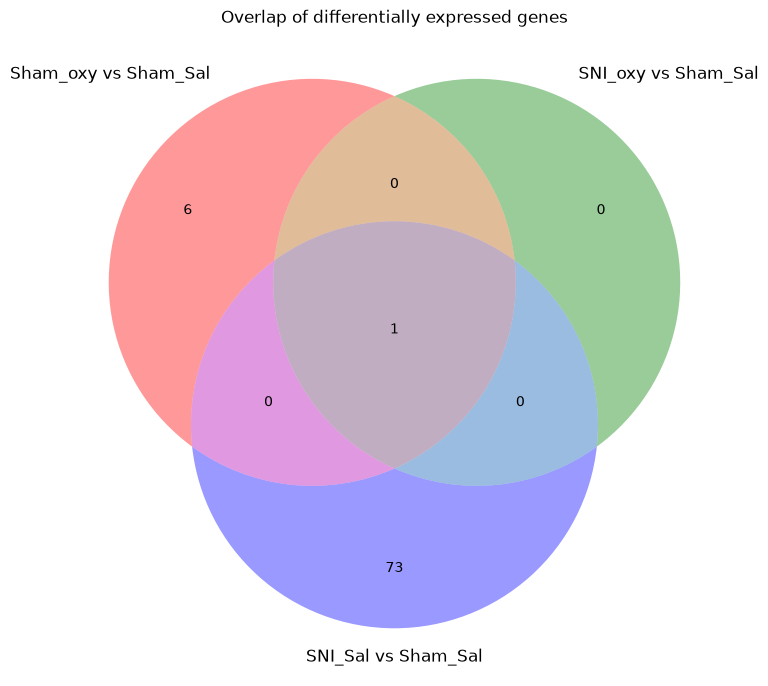

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3_unweighted
from pathlib import Path

# Find all DESeq2 result files
base = Path("differentialabundance_venn")
files = list(base.rglob("*.deseq2.results.tsv"))

# Locate contrast files
sham_file = next(
    f for f in files
    if f.name == "sham_oxy_vs_sham_sal_study.deseq2.results.tsv"
)

sni_oxy_file = next(
    f for f in files
    if f.name == "sni_oxy_vs_sham_sal_study.deseq2.results.tsv"
)

sni_sal_file = next(
    f for f in files
    if f.name == "sni_sal_vs_sham_sal_study.deseq2.results.tsv"
)

# Read DESeq2 results
sham_oxy = pd.read_csv(sham_file, sep="\t")
sni_oxy = pd.read_csv(sni_oxy_file, sep="\t")
sni_sal = pd.read_csv(sni_sal_file, sep="\t")

# Extract DEGs using the same criteria as the analysis
def get_deg_set(df):
    degs = df[
        (df["padj"] <= 0.05) &
        (df["log2FoldChange"].abs() >= 1)
    ]
    return set(degs["gene_id"].dropna())

A = get_deg_set(sham_oxy)
B = get_deg_set(sni_oxy)
C = get_deg_set(sni_sal)

# Check DEG counts
print("Sham_oxy vs Sham_Sal:", len(A))
print("SNI_oxy vs Sham_Sal:", len(B))
print("SNI_Sal vs Sham_Sal:", len(C))

# Venn diagram
plt.figure(figsize=(8, 8))

venn3_unweighted(
    [A, B, C],
    set_labels=(
        "Sham_oxy vs Sham_Sal",
        "SNI_oxy vs Sham_Sal",
        "SNI_Sal vs Sham_Sal"
    )
)

plt.title("Overlap of differentially expressed genes")
plt.tight_layout()

# Save figure
plt.savefig(
    "venn_DEGs_figure3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()